In [1]:
from pandas import read_csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
from pandas import read_csv
import math
import random
import csv
import numpy as np
import pandas as pd
from numpy import matrix
import statsmodels.api as sm
import pylab as pl
import scipy.linalg as sl

In [2]:
filename = 'XGDP 1.1 first with n = 400.csv'
data1 = read_csv(filename)
#Table1
print([data1['K1'].median(axis=0),(data1['K1'].mean(axis=0) - 2),
 np.std((data1.K1), ddof=1),(data1['RI1'].mean(axis=0)),np.sum(data1.K1 == 2)/len(data1.K1)])
print([data1['K2'].median(axis=0),(data1['K2'].mean(axis=0) - 2),
 np.std((data1.K2), ddof=1),(data1['RI2'].mean(axis=0)),np.sum(data1.K2 == 2)/len(data1.K2)])
print([data1.ACC1.mean(),data1.ACC2.mean(),data1.ACC_final.mean(),data1.ACCp1.mean(),data1.ACCp2.mean(),data1.ACC_pre.mean()])

[np.float64(2.0), np.float64(0.03500000000000014), np.float64(0.18424093903932007), np.float64(0.9797325187969925), np.float64(0.965)]
[np.float64(2.0), np.float64(0.015000000000000124), np.float64(0.12185748327926267), np.float64(0.9892174185463659), np.float64(0.985)]
[np.float64(0.9948875000000001), np.float64(0.9929125000000001), np.float64(0.99065), np.float64(0.987575), np.float64(0.9908750000000001), np.float64(0.9847999999999999)]


In [3]:
#Table2
#beta_0
print([data1.beta_0.mean(axis=0) - 1,np.std((data1.beta_0),ddof=1),
       data1.beta_0.var(axis=0)+ (data1.beta_0.mean(axis=0) - 1)**2])
#beta_1
print([data1.beta_1.mean(axis=0) - 1,np.std((data1.beta_1),ddof=1),
       data1.beta_1.var(axis=0)+ (data1.beta_1.mean(axis=0) - 1)**2])
#print([data1.beta_0.mean(axis=0) - 1,data1.beta_0.var(axis=0)])
#beta_2
print([data1.beta_2.mean(axis=0) - 1,np.std((data1.beta_2),ddof=1),
       data1.beta_2.var(axis=0)+ (data1.beta_2.mean(axis=0) - 1)**2])

#alpha1_1
print([data1.alpha1_1.mean(axis=0) + 1,np.std((data1.alpha1_1),ddof=1),
       data1.alpha1_1.var(axis=0)+ (data1.alpha1_1.mean(axis=0) + 1)**2])

#alpha12
print([data1.alpha1_2.mean(axis=0) - 1,np.std((data1.alpha1_2),ddof=1),
       data1.alpha1_2.var(axis=0)+ (data1.alpha1_2.mean(axis=0) - 1)**2])

#alpha21
print([data1.alpha2_1.mean(axis=0) + 1.5,np.std((data1.alpha2_1),ddof=1),
       data1.alpha2_1.var(axis=0)+ (data1.alpha2_1.mean(axis=0) + 1.5)**2])
#alpha22
print([data1.alpha2_2.mean(axis=0) -0.5,np.std((data1.alpha2_2),ddof=1),
       data1.alpha2_2.var(axis=0)+ (data1.alpha2_2.mean(axis=0) -0.5)**2])

[np.float64(0.007801252203060383), np.float64(0.08008087871102633), np.float64(0.006473806671065865)]
[np.float64(0.0020131232026765478), np.float64(0.12713906025870894), np.float64(0.01616839330849678)]
[np.float64(0.00013480553427958064), np.float64(0.027992159352641575), np.float64(0.0007835791577557516)]
[np.float64(0.005284674425143576), np.float64(0.08374761192251909), np.float64(0.0070415902865046285)]
[np.float64(-0.011147219427069532), np.float64(0.07529187425778625), np.float64(0.005793126830205531)]
[np.float64(-0.006453984608966623), np.float64(0.07880417697020793), np.float64(0.006251752225284629)]
[np.float64(-0.002056836780222948), np.float64(0.07909721860018201), np.float64(0.0062606005678254575)]


In [2]:
filename = 'XGDP 1.1 first with n = 400 pre1.csv'
pre1 = read_csv(filename)
filename = 'XGDP 1.1 first with n = 400 pre2.csv'
pre2 = read_csv(filename)
x_min,x_max = 0,1
y_min,y_max = 0,1
xx,yy = np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))#生成网格点

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


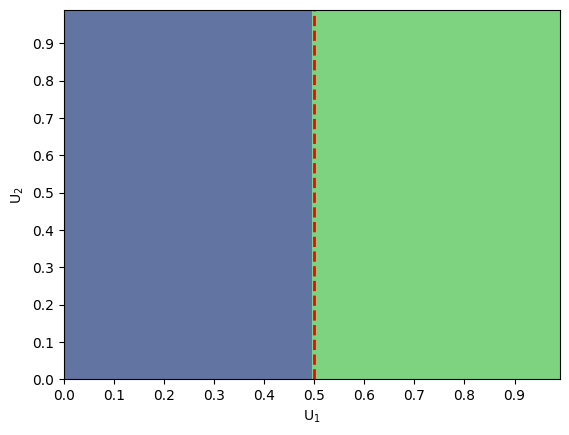

In [3]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,levels=1)

#plt.contourf(plon,plat,ssh,np.arange(-1,1.001,0.001))
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)

#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.5+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')


plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('img11.eps', format='eps', dpi=300)
#plt.savefig("img13.png")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


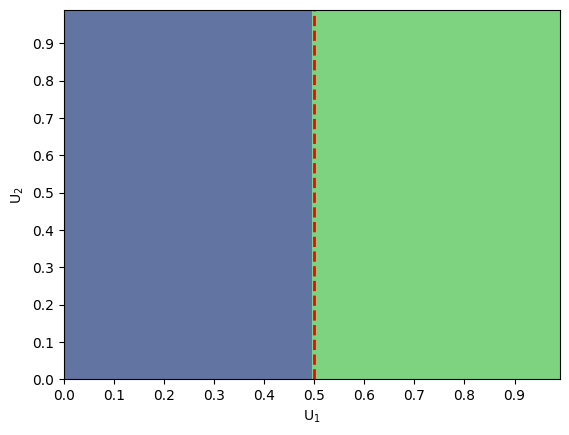

In [5]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,levels=1)

#plt.contourf(plon,plat,ssh,np.arange(-1,1.001,0.001))
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.5+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('img11.eps', format='eps', dpi=300)
#plt.savefig("img11.png")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


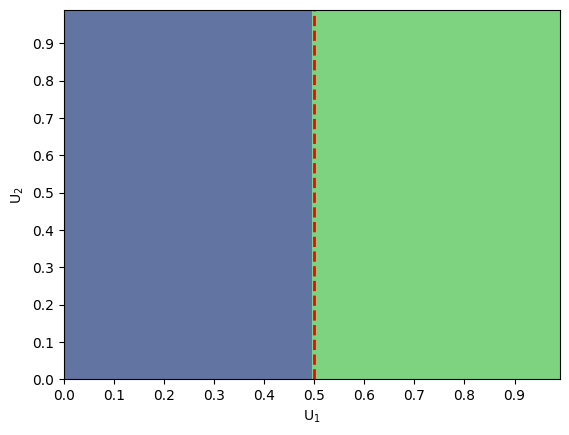

In [6]:
Pre2 = matrix(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8,levels=1)
#plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.Pastel2,alpha = 0.8)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.5+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')
plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)

plt.savefig('img12.eps', format='eps', dpi=300)
#plt.savefig("img12.png")
plt.show()
#beta1通过投票的最终预测

#### DGP1 n = 800 的输出

In [4]:
filename = 'XGDP 1.1 first with n = 800.csv'
data1_1 = read_csv(filename)
data1_1

,K1,K2,RI1,RI2,beta_0,beta_1,beta_2,alpha1_1,alpha1_2,alpha2_1,...,alpha1_1^{or},alpha1_2^{or},alpha2_1^{or},alpha2_2^{or},ACC1,ACCp1,ACC2,ACCp2,ACC_final,ACC_pre
0,2.0,2.0,0.987563,0.987563,0.976755,1.057007,0.980915,-0.902302,0.942093,-1.469677,...,-0.913037,0.934931,0.438928,-1.464752,0.99375,1.000,1.00000,1.000,0.99375,1.000
1,2.0,2.0,0.982631,0.982631,1.032108,1.003764,1.008844,-1.026713,0.930208,-1.535987,...,-1.035565,0.917034,0.478845,-1.541519,1.00000,1.000,0.99125,1.000,0.99125,1.000
2,2.0,2.0,0.996342,0.958401,1.013558,1.090330,0.970658,-1.026624,0.936107,-1.412394,...,-1.063392,0.971913,0.458016,-1.504519,1.00000,0.990,0.99250,0.990,0.99250,0.980
3,2.0,2.0,0.963157,0.963157,0.874794,1.251442,0.979953,-1.062145,0.936654,-1.342942,...,-1.052941,0.999677,0.451454,-1.411627,1.00000,0.995,0.98125,0.995,0.98125,0.995
4,2.0,2.0,1.000000,0.997500,1.009361,0.946330,1.005384,-0.981819,0.957553,-1.443592,...,-0.983717,0.949488,0.526730,-1.433006,0.99375,0.995,0.99375,1.000,0.99375,0.995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2.0,2.0,0.987563,0.986026,0.983131,1.007307,0.996957,-0.993811,1.039112,-1.529578,...,-0.992011,1.047459,0.511188,-1.533741,0.99000,0.995,0.99375,0.995,0.98375,0.995
196,2.0,2.0,0.977725,0.975282,0.988466,0.980414,1.019360,-1.071431,0.961350,-1.439587,...,-1.066662,1.007794,0.580466,-1.487403,0.99750,0.995,0.99125,0.995,0.98875,0.995
197,2.0,2.0,1.000000,0.975282,0.864683,1.122033,0.991103,-0.959712,1.093224,-1.437933,...,-0.965412,1.108006,0.485867,-1.445182,1.00000,1.000,0.98750,0.980,0.98750,0.980
198,2.0,2.0,1.000000,1.000000,1.039958,0.957468,1.003010,-0.937099,0.943388,-1.469664,...,-0.937099,0.943388,0.515429,-1.469664,0.99625,0.995,0.99625,0.995,0.99625,0.995


In [8]:
#Table1的数据的输出
print([data1_1['K1'].median(axis=0),(data1_1['K1'].mean(axis=0) - 2),
 np.std((data1_1.K1), ddof=1),(data1_1['RI1'].mean(axis=0)),np.sum(data1_1.K1 == 2)/len(data1_1.K1)])
print([data1_1['K2'].median(axis=0),(data1_1['K2'].mean(axis=0) - 2),
 np.std((data1_1.K2), ddof=1),(data1_1['RI2'].mean(axis=0)),np.sum(data1_1.K2 == 2)/len(data1_1.K2)])
print([data1_1.ACC1.mean(),data1_1.ACC2.mean(),data1_1.ACC_final.mean(),data1_1.ACCp1.mean(),data1_1.ACCp2.mean(),data1_1.ACC_pre.mean()])

[np.float64(2.0), np.float64(0.0), np.float64(0.0), np.float64(0.9795797246558198), np.float64(1.0)]
[np.float64(2.0), np.float64(0.0), np.float64(0.0), np.float64(0.9844678035043805), np.float64(1.0)]
[np.float64(0.996525), np.float64(0.99249375), np.float64(0.9907187500000001), np.float64(0.990825), np.float64(0.9917), np.float64(0.989375)]


In [9]:
#beta_0的输出
print([data1_1.beta_0.mean(axis=0) - 1,np.std((data1_1.beta_0),ddof=1),
       data1_1.beta_0.var(axis=0)+ (data1_1.beta_0.mean(axis=0) - 1)**2])
#beta_1的输出
print([data1_1.beta_1.mean(axis=0) - 1,np.std((data1_1.beta_1),ddof=1),
       data1_1.beta_1.var(axis=0)+ (data1_1.beta_1.mean(axis=0) - 1)**2])
#print([data1_1.beta_0.mean(axis=0) - 1,data1_1.beta_0.var(axis=0)])
#beta_2的输出
print([data1_1.beta_2.mean(axis=0) - 1,np.std((data1_1.beta_2),ddof=1),
       data1_1.beta_2.var(axis=0)+ (data1_1.beta_2.mean(axis=0) - 1)**2])

#alpha1_1的输出
print([data1_1.alpha1_1.mean(axis=0) + 1,np.std((data1_1.alpha1_1),ddof=1),
       data1_1.alpha1_1.var(axis=0)+ (data1_1.alpha1_1.mean(axis=0) + 1)**2])

#alpha12的输出
print([data1_1.alpha1_2.mean(axis=0) - 1,np.std((data1_1.alpha1_2),ddof=1),
       data1_1.alpha1_2.var(axis=0)+ (data1_1.alpha1_2.mean(axis=0) - 1)**2])

#alpha21的输出
print([data1_1.alpha2_1.mean(axis=0)+1.5,np.std((data1_1.alpha2_1),ddof=1),
       data1_1.alpha2_1.var(axis=0)+ (data1_1.alpha2_1.mean(axis=0) + 1.5)**2])
#alpha22的输出
print([data1_1.alpha2_2.mean(axis=0) - 0.5,np.std((data1_1.alpha2_2),ddof=1),
       data1_1.alpha2_2.var(axis=0)+ (data1_1.alpha2_2.mean(axis=0) - 0.5)**2])

[np.float64(-0.00390963403988176), np.float64(0.059228357088317266), np.float64(0.003523283521707024)]
[np.float64(0.007410405784854079), np.float64(0.09112069960051329), np.float64(0.008357896009583183)]
[np.float64(0.0006968528861106549), np.float64(0.017091327407519417), np.float64(0.0002925990764959052)]
[np.float64(0.018712476450251092), np.float64(0.05230187448123159), np.float64(0.003085642849151706)]
[np.float64(-0.012125308979307303), np.float64(0.06315391908639838), np.float64(0.004135440613815024)]
[np.float64(0.016118471825902203), np.float64(0.05549097638397739), np.float64(0.003339053594049539)]
[np.float64(-0.022273253272609483), np.float64(0.05275306857861728), np.float64(0.0032789840558061067)]


In [5]:
filename = 'XGDP 1.1 first with n = 800 pre1.csv'
pre1 = read_csv(filename)
filename = 'XGDP 1.1 first with n = 800 pre2.csv'
pre2 = read_csv(filename)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


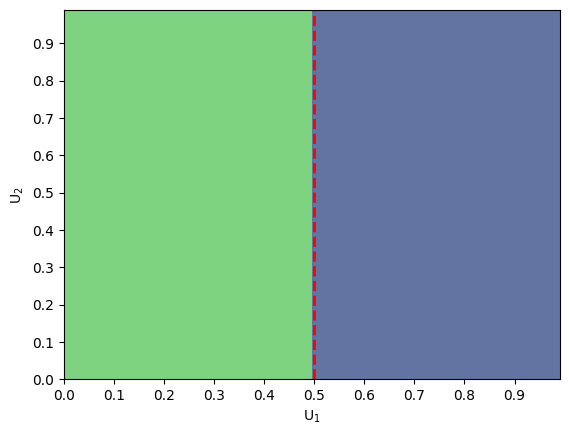

In [6]:
Pre1 = matrix(pre1).A
from collections import Counter
Pre_final1 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen1 = Pre1[:,i].reshape(1,-1)[0]
    fen_final1 = Counter(fen1).most_common()[0][0]
    Pre_final1.append(fen_final1)
Pre_final1 = np.array(Pre_final1).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final1,cmap = plt.cm.viridis,alpha = 0.8,levels=1)

#plt.contourf(plon,plat,ssh,np.arange(-1,1.001,0.001))
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.5+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')


plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('img13.eps', format='eps', dpi=300)
#plt.savefig("img13.png")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


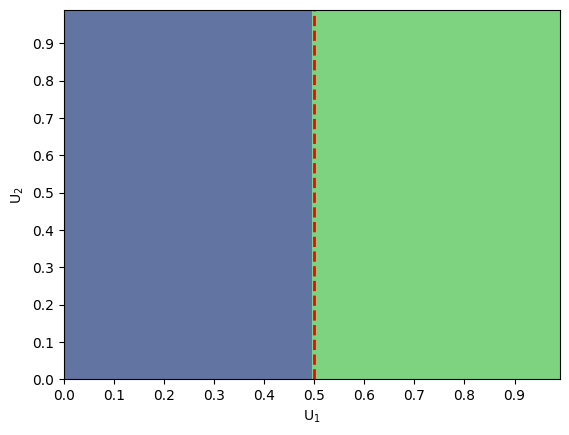

In [12]:
Pre2 = matrix(pre2).A
from collections import Counter
Pre_final2 = []
#进行投票，得到打的10000个点的最终预测，并将其可视化
for i in range(10000):
    fen2 = Pre2[:,i].reshape(1,-1)[0]
    fen_final2 = Counter(fen2).most_common()[0][0]
    Pre_final2.append(fen_final2)
Pre_final2 = np.array(Pre_final2).reshape(xx.shape)
plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.viridis,alpha = 0.8,levels=1)
#plt.contourf(xx,yy,Pre_final2,cmap = plt.cm.Pastel2,alpha = 0.8)
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())
my_x_ticks = np.arange(0, 1, 0.1)
#对比范围和名称的区别
#my_x_ticks = np.arange(-5, 2, 0.5)
my_y_ticks = np.arange(0, 1, 0.1)
plt.xticks(my_x_ticks)
plt.yticks(my_y_ticks)
y1 = np.linspace(0, 1, 50)
x = 0.5+ y1-y1
plt.plot(x, y1, color='red',linewidth=2.0, linestyle='--')

plt.xlabel('U$_1$',fontsize=10)
plt.ylabel('U$_2$',fontsize=10)
plt.savefig('img14.eps', format='eps', dpi=300)
plt.show()
#beta1通过投票的最终预测